In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import warnings
warnings.filterwarnings('ignore')

### 범주형 변수

In [3]:
import os
# 이 파일은 열 이름을 나타내는 헤더가 없으므로 header=None으로 저장하고 'names' 매개변수로 열 이름을 제공합니다
data = pd.read_csv(os.path.join(mglearn.datasets.DATA_PATH, 'adult.data'), header=None, index_col=False,
                   names=['age','workclass','fnlwgt','education','education-num','marital-status','occupation',
                          'relationship','race','gender','capital-gain','capital-loss','hours-per-week','native-country','income'])
# 예제를 위해 몇개의 열만 선택합니다
data = data[['age','workclass','education','gender','hours-per-week','occupation','income']]
data.head()

,age,workclass,education,gender,hours-per-week,occupation,income
0,39,State-gov,Bachelors,Male,40,Adm-clerical,<=50K
1,50,Self-emp-not-inc,Bachelors,Male,13,Exec-managerial,<=50K
2,38,Private,HS-grad,Male,40,Handlers-cleaners,<=50K
3,53,Private,11th,Male,40,Handlers-cleaners,<=50K
4,28,Private,Bachelors,Female,40,Prof-specialty,<=50K


In [4]:
print(data.gender.value_counts())

 Male      21790
 Female    10771
Name: gender, dtype: int64


In [5]:
print('org feature:\n', list(data.columns), '\n')
data_dummies = pd.get_dummies(data)
print('get_dummies after feature:\n', list(data_dummies.columns))

org feature:
 ['age', 'workclass', 'education', 'gender', 'hours-per-week', 'occupation', 'income'] 

get_dummies after feature:
 ['age', 'hours-per-week', 'workclass_ ?', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private', 'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc', 'workclass_ State-gov', 'workclass_ Without-pay', 'education_ 10th', 'education_ 11th', 'education_ 12th', 'education_ 1st-4th', 'education_ 5th-6th', 'education_ 7th-8th', 'education_ 9th', 'education_ Assoc-acdm', 'education_ Assoc-voc', 'education_ Bachelors', 'education_ Doctorate', 'education_ HS-grad', 'education_ Masters', 'education_ Preschool', 'education_ Prof-school', 'education_ Some-college', 'gender_ Female', 'gender_ Male', 'occupation_ ?', 'occupation_ Adm-clerical', 'occupation_ Armed-Forces', 'occupation_ Craft-repair', 'occupation_ Exec-managerial', 'occupation_ Farming-fishing', 'occupation_ Handlers-cleaners', 'occupation_ Machine-op-inspct',

In [6]:
data_dummies.head()

,age,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving,income_ <=50K,income_ >50K
0,39,40,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,50,13,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,38,40,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,53,40,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,28,40,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [7]:
features = data_dummies.loc[:, 'age':'occupation_ Transport-moving']
# NumPy 배열 추출
x = features.values
y = data_dummies['income_ >50K'].values
print('x.shape:{}, y.shape:{}'.format(x.shape, y.shape))

x.shape:(32561, 44), y.shape:(32561,)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)
print('test score: {:.2f}'.format(logreg.score(x_test, y_test)))

test score: 0.81


In [11]:
# 숫자 특성과 범주형 문자열 특성을 가진 DataFrame을 만듭니다
demo_df = pd.DataFrame({'int feature':[0,1,2,1],
                        'obj feature':['a','b','a','d']})
demo_df

,int feature,obj feature
0,0,a
1,1,b
2,2,a
3,1,d


In [12]:
pd.get_dummies(demo_df)

,int feature,obj feature_a,obj feature_b,obj feature_d
0,0,1,0,0
1,1,0,1,0
2,2,1,0,0
3,1,0,0,1


In [13]:
demo_df['int feature'] = demo_df['int feature'].astype(str)
pd.get_dummies(demo_df, columns=['int feature','obj feature'])

,int feature_0,int feature_1,int feature_2,obj feature_a,obj feature_b,obj feature_d
0,1,0,0,1,0,0
1,0,1,0,0,1,0
2,0,0,1,1,0,0
3,0,1,0,0,0,1


In [14]:
from sklearn.preprocessing import OneHotEncoder
# sparse=False로 설정하면 OneHotEncoder가 희소 행렬이 아니라 넘파이 배열을 반환합니다
ohe = OneHotEncoder(sparse=False)
print(ohe.fit_transform(demo_df))

[[1. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 1. 0. 0.]
 [0. 1. 0. 0. 0. 1.]]


In [15]:
print(ohe.get_feature_names_out())

['int feature_0' 'int feature_1' 'int feature_2' 'obj feature_a'
 'obj feature_b' 'obj feature_d']


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

ct = ColumnTransformer(
        [('scaling', StandardScaler(), ['age','hours-per-week']),
         ('onehot', OneHotEncoder(sparse=False), ['workclass','education','gender','occupation'])])

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
# income을 제외한 모든 열을 추출합니다
data_features = data.drop('income', axis=1)
# 데이터프레임과 income을 분할합니다
x_train, x_test, y_train, y_test = train_test_split(data_features, data.income, random_state=0)

ct.fit(x_train)
x_train_trans = ct.transform(x_train)
print(x_train_trans.shape)

(24420, 44)


In [18]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train_trans, y_train)

x_test_trans = ct.transform(x_test)
print('test set score: {:.2f}'.format(logreg.score(x_test_trans, y_test)))

test set score: 0.81


In [19]:
ct.named_transformers_.onehot

OneHotEncoder(sparse=False)

In [20]:
from sklearn.compose import make_column_transformer
ct = make_column_transformer(
        (StandardScaler(), ['age','hours-per-week']),
        (OneHotEncoder(sparse=False), ['workclass','eudcation','gender','occupation']))

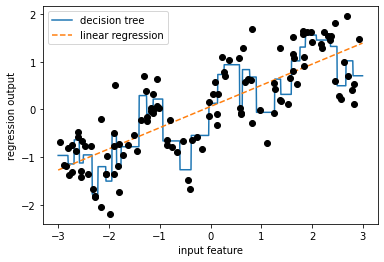

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

x, y = mglearn.datasets.make_wave(n_samples=120)
line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1,1)

reg = DecisionTreeRegressor(min_samples_leaf=3).fit(x, y)
plt.plot(line, reg.predict(line), label='decision tree')

reg = LinearRegression().fit(x, y)
plt.plot(line, reg.predict(line), '--', label='linear regression')
plt.plot(x[:,0], y, 'o', c='k')
plt.ylabel('regression output')
plt.xlabel('input feature')
plt.legend(loc='best')

In [24]:
from sklearn.preprocessing import KBinsDiscretizer

In [25]:
kb = KBinsDiscretizer(n_bins=10, strategy='uniform')
kb.fit(x)
print('bin edges: \n', kb.bin_edges_)

bin edges: 
 [array([-2.9668673 , -2.37804841, -1.78922951, -1.20041062, -0.61159173,
        -0.02277284,  0.56604605,  1.15486494,  1.74368384,  2.33250273,
         2.92132162])                                                   ]


In [26]:
x_binned = kb.transform(x)
x_binned

<120x10 sparse matrix of type '<class 'numpy.float64'>'
	with 120 stored elements in Compressed Sparse Row format>

In [27]:
print(x[:10])
x_binned.toarray()[:10]

[[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]
 [-2.06403288]
 [-2.65149833]
 [ 2.19705687]
 [ 0.60669007]
 [ 1.24843547]]


array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]])

In [28]:
kb = KBinsDiscretizer(n_bins=10, strategy='uniform', encode='onehot-dense')
kb.fit(x)
x_binned = kb.transform(x)

Text(0.5, 0, 'input feature')

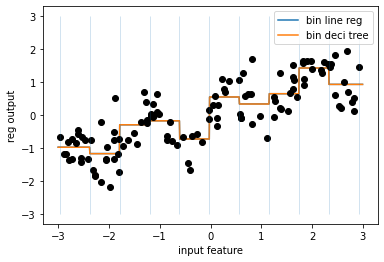

In [30]:
line_binned = kb.transform(line)

reg = LinearRegression().fit(x_binned, y)
plt.plot(line, reg.predict(line_binned), label='bin line reg')

reg = DecisionTreeRegressor(min_samples_split=3).fit(x_binned, y)
plt.plot(line, reg.predict(line_binned), label='bin deci tree')
plt.plot(x[:,0], y, 'o', c='k')
plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=.2)
plt.legend(loc='best')
plt.ylabel('reg output')
plt.xlabel('input feature')

In [31]:
x_combined = np.hstack([x, x_binned])
print(x_combined.shape)

(120, 11)


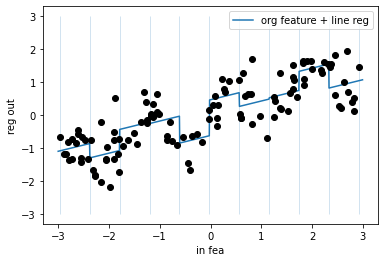

In [33]:
reg = LinearRegression().fit(x_combined, y)

line_combined = np.hstack([line, line_binned])
plt.plot(line, reg.predict(line_combined), label='org feature + line reg')

plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=.2)
plt.legend(loc='best')
plt.ylabel('reg out')
plt.xlabel('in fea')
plt.plot(x[:,0], y, 'o', c='k')

In [34]:
x_product = np.hstack([x_binned, x * x_binned])
print(x_product.shape)

(120, 20)


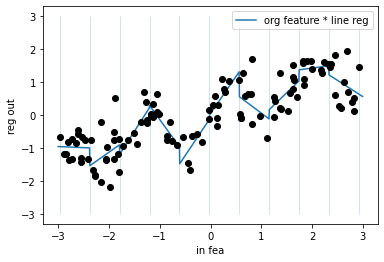

In [36]:
reg = LinearRegression().fit(x_product, y)

line_product = np.hstack([line_binned, line * line_binned])
plt.plot(line, reg.predict(line_product), label='org feature * line reg')

plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=.2)

plt.plot(x[:,0], y, 'o', c='k')
plt.ylabel('reg out')
plt.xlabel('in fea')
plt.legend(loc='best')

In [37]:
from sklearn.preprocessing import PolynomialFeatures

# x ** 10까지 고차항을 추가합니다
# 기본값인 'include_bias=True'는 절편에 해당하는 1인 특성을 추가합니다
poly = PolynomialFeatures(degree=10, include_bias=False)
poly.fit(x)
x_poly = poly.transform(x)

In [38]:
print('x_poly.shape:', x_poly.shape)

x_poly.shape: (120, 10)


In [39]:
print('x feature:\n', x[:5])
print('x_poly feature:\n', x_poly[:5])

x feature:
 [[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]
x_poly feature:
 [[-7.52759287e-01  5.66646544e-01 -4.26548448e-01  3.21088306e-01
  -2.41702204e-01  1.81943579e-01 -1.36959719e-01  1.03097700e-01
  -7.76077513e-02  5.84199555e-02]
 [ 2.70428584e+00  7.31316190e+00  1.97768801e+01  5.34823369e+01
   1.44631526e+02  3.91124988e+02  1.05771377e+03  2.86036036e+03
   7.73523202e+03  2.09182784e+04]
 [ 1.39196365e+00  1.93756281e+00  2.69701700e+00  3.75414962e+00
   5.22563982e+00  7.27390068e+00  1.01250053e+01  1.40936394e+01
   1.96178338e+01  2.73073115e+01]
 [ 5.91950905e-01  3.50405874e-01  2.07423074e-01  1.22784277e-01
   7.26822637e-02  4.30243318e-02  2.54682921e-02  1.50759786e-02
   8.92423917e-03  5.28271146e-03]
 [-2.06388816e+00  4.25963433e+00 -8.79140884e+00  1.81444846e+01
  -3.74481869e+01  7.72888694e+01 -1.59515582e+02  3.29222321e+02
  -6.79478050e+02  1.40236670e+03]]


In [40]:
print('feature name:\n', poly.get_feature_names_out())

feature name:
 ['x0' 'x0^2' 'x0^3' 'x0^4' 'x0^5' 'x0^6' 'x0^7' 'x0^8' 'x0^9' 'x0^10']


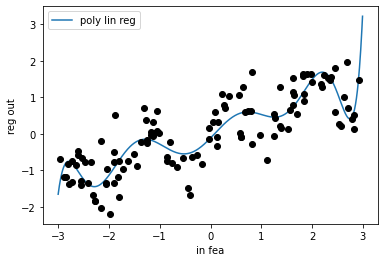

In [42]:
reg = LinearRegression().fit(x_poly, y)

line_poly = poly.transform(line)
plt.plot(line, reg.predict(line_poly), label='poly lin reg')
plt.plot(x[:,0], y, 'o', c='k')
plt.ylabel('reg out')
plt.xlabel('in fea')
plt.legend(loc='best')

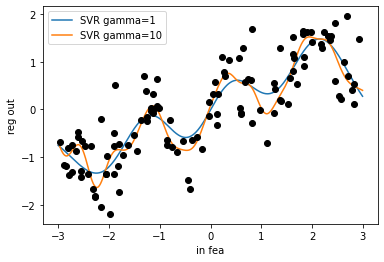

In [43]:
from sklearn.svm import SVR

for gamma in [1,10]:
    svr = SVR(gamma=gamma).fit(x, y)
    plt.plot(line, svr.predict(line), label='SVR gamma={}'.format(gamma))
    
plt.plot(x[:,0], y, 'o', c='k')
plt.ylabel('reg out')
plt.xlabel('in fea')
plt.legend(loc='best')

In [44]:
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

boston = load_boston()
x_train, x_test, y_train, y_test = train_test_split(boston.data, boston.target, random_state=0)

# 데이터 스케일 조정
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [45]:
poly = PolynomialFeatures(degree=2).fit(x_train_scaled)
x_train_poly = poly.transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled)
print('x_train.shape:',x_train.shape)
print('x_train_poly.shape:', x_train_poly.shape)

x_train.shape: (379, 13)
x_train_poly.shape: (379, 105)


In [46]:
print('poly fea name:\n', poly.get_feature_names())

poly fea name:
 ['1', 'x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x0^2', 'x0 x1', 'x0 x2', 'x0 x3', 'x0 x4', 'x0 x5', 'x0 x6', 'x0 x7', 'x0 x8', 'x0 x9', 'x0 x10', 'x0 x11', 'x0 x12', 'x1^2', 'x1 x2', 'x1 x3', 'x1 x4', 'x1 x5', 'x1 x6', 'x1 x7', 'x1 x8', 'x1 x9', 'x1 x10', 'x1 x11', 'x1 x12', 'x2^2', 'x2 x3', 'x2 x4', 'x2 x5', 'x2 x6', 'x2 x7', 'x2 x8', 'x2 x9', 'x2 x10', 'x2 x11', 'x2 x12', 'x3^2', 'x3 x4', 'x3 x5', 'x3 x6', 'x3 x7', 'x3 x8', 'x3 x9', 'x3 x10', 'x3 x11', 'x3 x12', 'x4^2', 'x4 x5', 'x4 x6', 'x4 x7', 'x4 x8', 'x4 x9', 'x4 x10', 'x4 x11', 'x4 x12', 'x5^2', 'x5 x6', 'x5 x7', 'x5 x8', 'x5 x9', 'x5 x10', 'x5 x11', 'x5 x12', 'x6^2', 'x6 x7', 'x6 x8', 'x6 x9', 'x6 x10', 'x6 x11', 'x6 x12', 'x7^2', 'x7 x8', 'x7 x9', 'x7 x10', 'x7 x11', 'x7 x12', 'x8^2', 'x8 x9', 'x8 x10', 'x8 x11', 'x8 x12', 'x9^2', 'x9 x10', 'x9 x11', 'x9 x12', 'x10^2', 'x10 x11', 'x10 x12', 'x11^2', 'x11 x12', 'x12^2']


In [48]:
from sklearn.linear_model import Ridge
ridge = Ridge().fit(x_train_scaled, y_train)
print('interaction feature o score: {:.3f}'.format(ridge.score(x_test_scaled, y_test)))
ridge = Ridge().fit(x_train_poly, y_train)
print('interaction feature x score: {:.3f}'.format(ridge.score(x_test_poly, y_test)))

interaction feature o score: 0.621
interaction feature x score: 0.753


In [50]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(x_train_scaled, y_train)
print('interaction feature o score: {:.3f}'.format(rf.score(x_test_scaled, y_test)))
rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(x_train_poly, y_train)
print('interaction feature x score: {:.3f}'.format(rf.score(x_test_poly, y_test)))

interaction feature o score: 0.795
interaction feature x score: 0.775


In [52]:
rnd = np.random.RandomState(0)
x_org = rnd.normal(size=(1000,3))
w = rnd.normal(size=3)

x = rnd.poisson(10 * np.exp(x_org))
y = np.dot(x_org, w)
print(x[:10,0])

[ 56  81  25  20  27  18  12  21 109   7]


In [53]:
print('feature count:\n', np.bincount(x[:,0]))

feature count:
 [28 38 68 48 61 59 45 56 37 40 35 34 36 26 23 26 27 21 23 23 18 21 10  9
 17  9  7 14 12  7  3  8  4  5  5  3  4  2  4  1  1  3  2  5  3  8  2  5
  2  1  2  3  3  2  2  3  3  0  1  2  1  0  0  3  1  0  0  0  1  3  0  1
  0  2  0  1  1  0  0  0  0  1  0  0  2  2  0  1  1  0  0  0  0  1  1  0
  0  0  0  0  0  0  1  0  0  0  0  0  1  1  0  0  1  0  0  0  0  0  0  0
  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]


Text(0.5, 0, 'value')

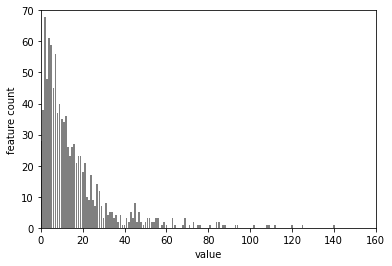

In [54]:
plt.xlim(0,160)
plt.ylim(0,70)
bins = np.bincount(x[:,0])
plt.bar(range(len(bins)), bins, color='grey')
plt.ylabel('feature count')
plt.xlabel('value')

In [55]:
from sklearn.linear_model import Ridge
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
score = Ridge().fit(x_train, y_train).score(x_test, y_test)
print('test score: {:.3f}'.format(score))

test score: 0.622


In [56]:
x_train_log = np.log(x_train + 1)
x_test_log = np.log(x_test + 1)

Text(0.5, 0, 'value')

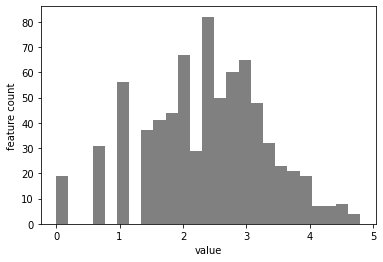

In [57]:
plt.hist(x_train_log[:,0], bins=25, color='grey')
plt.ylabel('feature count')
plt.xlabel('value')

In [58]:
score = Ridge().fit(x_train_log, y_train).score(x_test_log, y_test)
print('test score: {:.3f}'.format(score))

test score: 0.875


In [59]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

# 고정된 난수를 발생시킵니다
rng = np.random.RandomState(42)
noise = rng.normal(size=(len(cancer.data), 50))
# 데이터에 노이즈 특성을 추가합니다
# 처음 30개는 원본 특성이고 다음 50개는 노이즈입니다
x_w_noise = np.hstack([cancer.data, noise])

x_train, x_test, y_train, y_test = train_test_split(x_w_noise, cancer.target, random_state=0, test_size=.5)
# f_classif(기본값)와 SelectPercentile을 사용하여 특성의 50%를 선택합니다
select = SelectPercentile(score_func=f_classif, percentile=50)
select.fit(x_train, y_train)
# 훈련 세트에 적용합니다
x_train_selected = select.transform(x_train)

print('x_train.shape:', x_train.shape)
print('x_train_selected.shape:', x_train_selected.shape)

x_train.shape: (284, 80)
x_train_selected.shape: (284, 40)


[ True  True  True  True  True  True  True  True  True False  True False
  True  True  True  True  True  True False False  True  True  True  True
  True  True  True  True  True  True False False False  True False  True
 False False  True False False False False  True False False  True False
 False  True False  True False False False False False False  True False
  True False False False False  True False  True False False False False
  True  True False  True False False False False]


([<matplotlib.axis.YTick at 0x2340d624a60>], [Text(0, 0, '')])

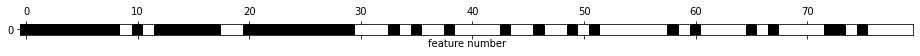

In [62]:
mask = select.get_support()
print(mask)
# True는 검은색, False는 흰색으로 마스킹합니다
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel('feature number')
plt.yticks([0])

In [64]:
from sklearn.linear_model import LogisticRegression

# 테스트 데이터 변환
x_test_selected = select.transform(x_test)

lr = LogisticRegression(max_iter=5000)
lr.fit(x_train, y_train)
print('all feature used score: {:.3f}'.format(lr.score(x_test, y_test)))
lr.fit(x_train_selected, y_train)
print('selected feature used score: {:.3f}'.format(lr.score(x_test_selected, y_test)))

all feature used score: 0.947
selected feature used score: 0.933


In [66]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
select = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold='median')

In [67]:
select.fit(x_train, y_train)
x_train_l1 = select.transform(x_train)
print('x_train.shape:', x_train.shape)
print('x_train_l1.shape:', x_train_l1.shape)

x_train.shape: (284, 80)
x_train_l1.shape: (284, 40)


([<matplotlib.axis.YTick at 0x2340d7127f0>], [Text(0, 0, '')])

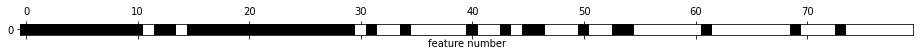

In [69]:
mask = select.get_support()
# True는 검은색, False는 흰색으로 마스킹합니다
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel('feature number')
plt.yticks([0])

In [70]:
x_test_l1 = select.transform(x_test)
score = LogisticRegression(max_iter=5000).fit(x_train_l1, y_train).score(x_test_l1, y_test)
print('test score: {:.3f}'.format(score))

test score: 0.947


([<matplotlib.axis.YTick at 0x2340e95bc10>], [Text(0, 0, '')])

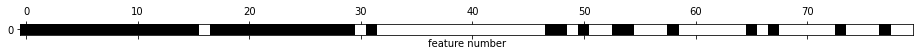

In [71]:
from sklearn.feature_selection import RFE
select = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=40)

select.fit(x_train, y_train)
# 선택된 특성을 표시합니다
mask = select.get_support()
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel('feature number')
plt.yticks([0])

In [72]:
x_train_rfe = select.transform(x_train)
x_test_rfe = select.transform(x_test)

score = LogisticRegression(max_iter=5000).fit(x_train_rfe, y_train).score(x_test_rfe, y_test)
print('test score: {:.3f}'.format(score))

test score: 0.940


In [73]:
print('test score: {:.3f}'.format(select.score(x_test, y_test)))

test score: 0.951


In [74]:
citibike = mglearn.datasets.load_citibike()

In [75]:
print('citibike data:\n', citibike.head())

citibike data:
 starttime
2015-08-01 00:00:00     3
2015-08-01 03:00:00     0
2015-08-01 06:00:00     9
2015-08-01 09:00:00    41
2015-08-01 12:00:00    39
Freq: 3H, Name: one, dtype: int64


Text(0, 0.5, 'rent count')

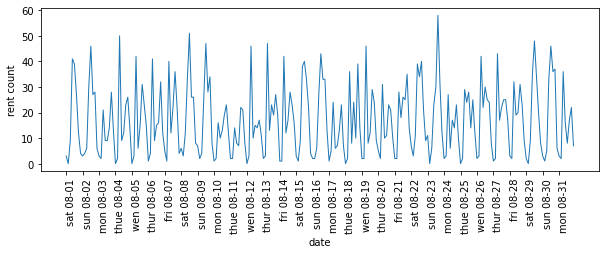

In [77]:
plt.figure(figsize=(10,3))
xticks = pd.date_range(start=citibike.index.min(), end=citibike.index.max(), freq='D')
week = ['sun','mon','thue','wen','thur','fri','sat']
xticks_name = [week[int(w)] + d for w, d in zip(xticks.strftime('%w'), xticks.strftime(' %m-%d'))]
plt.xticks(xticks, xticks_name, rotation=90, ha='left')
plt.plot(citibike, linewidth=1)
plt.xlabel('date')
plt.ylabel('rent count')

In [78]:
# 타깃 값 추출(대여 횟수)
y = citibike.values
# POSIX 시간을 10**9로 나누어 변환
x = citibike.index.astype('int64').values.reshape(-1,1) // 10**9

In [81]:
# 처음 184개 데이터 포인트를 훈련 세트로 사용하고 나머지는 테스트 세트로 사용합니다
n_train = 184

# 주어진 특성을 사용하여 평가하고 그래프르 만듭니다
def eval_on_features(features, target, regressor):
    # 훈련 세트와 테스트 세트로 나눕니다
    x_train, x_test = features[:n_train], features[n_train:]
    # 타깃 값도 나눕니다
    y_train, y_test = target[:n_train], target[n_train:]
    regressor.fit(x_train, y_train)
    print('test set R^2: {:.2f}'.format(regressor.score(x_test, y_test)))
    y_pred = regressor.predict(x_test)
    y_pred_train = regressor.predict(x_train)
    plt.figure(figsize=(10,3))
    
    plt.xticks(range(0, len(x), 8), xticks_name, rotation=90, ha='left')
    
    plt.plot(range(n_train), y_train, label='train')
    plt.plot(range(n_train, len(y_test) + n_train), y_test, '-', label='test')
    plt.plot(range(n_train), y_pred_train, '--', label='train pred')
    
    plt.plot(range(n_train, len(y_test) + n_train), y_pred, '--', label='test pred')
    plt.legend(loc=(1.01, 0))
    plt.xlabel('date')
    plt.ylabel('rent count')

test set R^2: -0.04


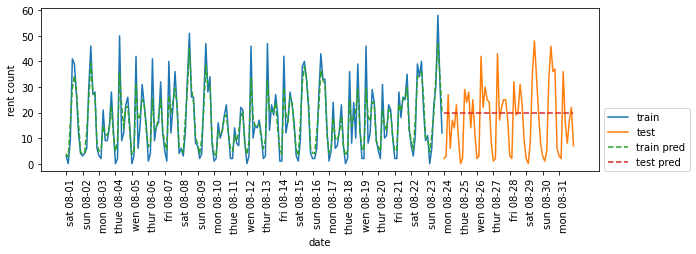

In [82]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100, random_state=0)
eval_on_features(x, y, regressor)

test set R^2: 0.60


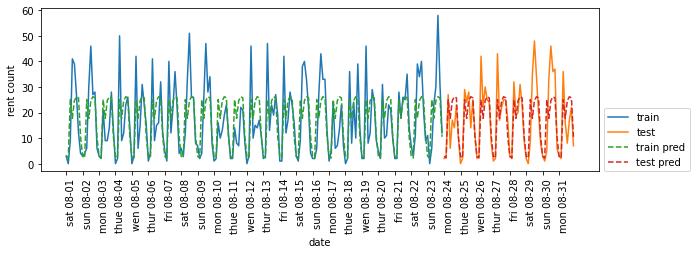

In [83]:
x_hour = citibike.index.hour.values.reshape(-1,1)
eval_on_features(x_hour, y, regressor)

test set R^2: 0.84


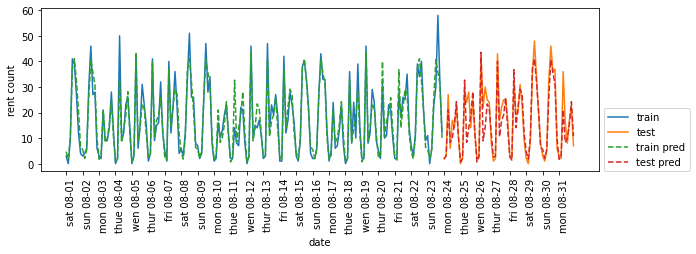

In [84]:
x_hour_week = np.hstack([citibike.index.dayofweek.values.reshape(-1,1),
                         citibike.index.hour.values.reshape(-1,1)])
eval_on_features(x_hour_week, y, regressor)

test set R^2: 0.13


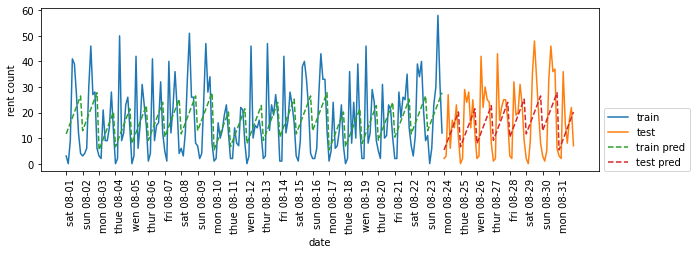

In [85]:
from sklearn.linear_model import LinearRegression
eval_on_features(x_hour_week, y, LinearRegression())

In [86]:
enc = OneHotEncoder()
x_hour_week_onehot = enc.fit_transform(x_hour_week).toarray()

test set R^2: 0.62


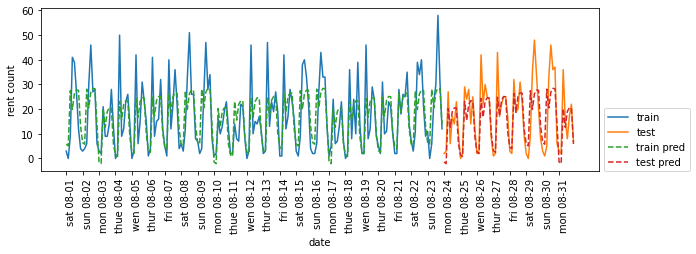

In [89]:
eval_on_features(x_hour_week_onehot, y, Ridge())

test set R^2: 0.85


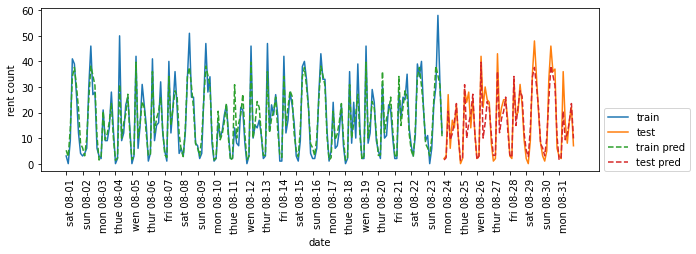

In [90]:
poly_transformer = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
x_hour_week_onehot_poly = poly_transformer.fit_transform(x_hour_week_onehot)
lr = Ridge()
eval_on_features(x_hour_week_onehot_poly, y, lr)

In [91]:
hour = ['%02d:00' % i for i in range(0, 24, 3)]
day = ['mon','tue','wen','thr','fri','sat','sun']
features = day + hour

In [92]:
features_poly = poly_transformer.get_feature_names_out(features)
features_nonzero = np.array(features_poly)[lr.coef_ != 0]
coef_nonzero = lr.coef_[lr.coef_ != 0]

Text(0, 0.5, 'coeffient size')

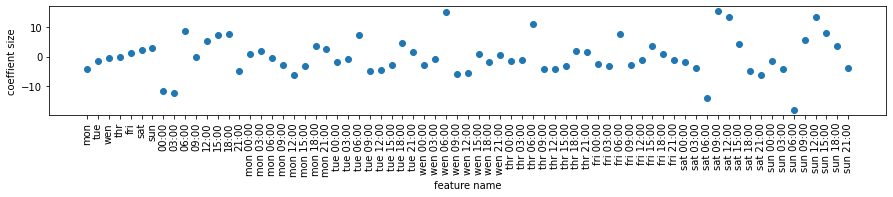

In [93]:
plt.figure(figsize=(15,2))
plt.plot(coef_nonzero, 'o')
plt.xticks(np.arange(len(coef_nonzero)), features_nonzero, rotation=90)
plt.xlabel('feature name')
plt.ylabel('coeffient size')